In [2]:
!pip install matplotlib seaborn



[notice] A new release of pip is available: 25.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Titanic Dataset - Exploratory Data Analysis
# MSDS25050 - Tools & Techniques for Data Science
# Imaan Mufti

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visualizations
plt.style.use('ggplot')
sns.set_palette("husl")

# Display all columns
pd.set_option('display.max_columns', 200)

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
df = pd.read_csv('../data/Titanic-Dataset.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Number of passengers: {len(df)}")

df.head()

Dataset loaded successfully!
Shape: (891, 12)
Number of passengers: 891


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
print("=== DATASET OVERVIEW ===")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024 ** 2:.2f} MB")

print("\n" + "="*50)
print("DETAILED INFO:")
print("="*50)
df.info()

=== DATASET OVERVIEW ===
Dataset Shape: 891 rows, 12 columns
Memory Usage: 0.28 MB

DETAILED INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
print("=== STATISTICAL SUMMARY ===")
print(df.describe())

print("\n=== CATEGORICAL VARIABLES ===")
print(df[['Survived', 'Pclass', 'Sex', 'Embarked']].value_counts())

=== STATISTICAL SUMMARY ===
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  

=== CATEGORICAL VARIABLES ===
Survived  Pclass  Sex 

In [7]:
print("=== DATA TYPE CONVERSIONS ===")
print("Before conversion:")
print(df[['Survived', 'Pclass', 'Sex', 'Embarked']].dtypes)

df['Survived'] = df['Survived'].astype('category')
df['Pclass'] = df['Pclass'].astype('category')
df['Sex'] = df['Sex'].astype('category')
df['Embarked'] = df['Embarked'].astype('category')

print("\nAfter conversion:")
print(df[['Survived', 'Pclass', 'Sex', 'Embarked']].dtypes)

print(f"\nMemory after optimization: {df.memory_usage(deep=True).sum() / 1024 ** 2:.2f} MB")

=== DATA TYPE CONVERSIONS ===
Before conversion:
Survived     int64
Pclass       int64
Sex         object
Embarked    object
dtype: object

After conversion:
Survived    category
Pclass      category
Sex         category
Embarked    category
dtype: object

Memory after optimization: 0.18 MB


=== MISSING VALUES ANALYSIS ===
          Missing Count  Missing Percentage
Age                 177           19.865320
Cabin               687           77.104377
Embarked              2            0.224467


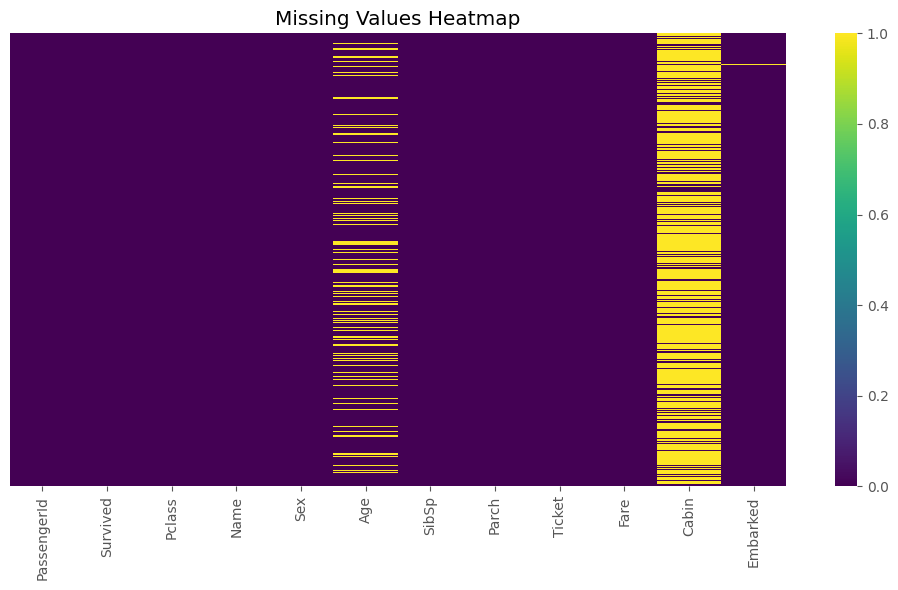

In [8]:
print("=== MISSING VALUES ANALYSIS ===")
missing_data = df.isna().sum()
missing_percent = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percent
})
print(missing_df[missing_df['Missing Count'] > 0])

plt.figure(figsize=(10, 6))
sns.heatmap(df.isna(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

In [9]:
print("=== HANDLING MISSING VALUES ===")

df_clean = df.copy()

embarked_mode = df_clean['Embarked'].mode()[0]
df_clean['Embarked'] = df_clean['Embarked'].fillna(embarked_mode)
print(f"Embarked: Filled 2 missing values with '{embarked_mode}'")

age_median = df_clean['Age'].median()
df_clean['Age'] = df_clean['Age'].fillna(age_median)
print(f"Age: Filled 177 missing values with median {age_median}")

df_clean['Has_Cabin'] = df_clean['Cabin'].notna().astype('category')
print(f"Cabin: Created 'Has_Cabin' indicator (True/False) instead of imputing")

missing_excluding_cabin = df_clean.drop('Cabin', axis=1).isna().sum().sum()
print(f"\nRemaining missing values (excluding Cabin): {missing_excluding_cabin}")

print("\nUpdated missing values summary:")
print(df_clean.isna().sum()[df_clean.isna().sum() > 0])

=== HANDLING MISSING VALUES ===
Embarked: Filled 2 missing values with 'S'
Age: Filled 177 missing values with median 28.0
Cabin: Created 'Has_Cabin' indicator (True/False) instead of imputing

Remaining missing values (excluding Cabin): 0

Updated missing values summary:
Cabin    687
dtype: int64


In [10]:
print("=== ORIGINAL DATASET (df) - STILL HAS MISSING VALUES ===")
print(df.isna().sum()[df.isna().sum() > 0])

print("\n=== CLEANED DATASET (df_clean) - MISSING VALUES HANDLED ===")
print(df_clean.isna().sum()[df_clean.isna().sum() > 0])

=== ORIGINAL DATASET (df) - STILL HAS MISSING VALUES ===
Age         177
Cabin       687
Embarked      2
dtype: int64

=== CLEANED DATASET (df_clean) - MISSING VALUES HANDLED ===
Cabin    687
dtype: int64


In [11]:
# Feature Engineering
print("=== FEATURE ENGINEERING ===")

df_clean['Title'] = df_clean['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
print(f"Titles extracted: {df_clean['Title'].value_counts().to_dict()}")

df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1

df_clean['IsAlone'] = (df_clean['FamilySize'] == 1).astype('category')

df_clean['AgeGroup'] = pd.cut(df_clean['Age'], bins=[0, 12, 18, 35, 60, 100], 
                              labels=['Child', 'Teen', 'Adult', 'Middle', 'Senior'])

df_clean['FareGroup'] = pd.qcut(df_clean['Fare'], 4, labels=['Low', 'Medium', 'High', 'Very High'])

print(f"New features: Title, FamilySize, IsAlone, AgeGroup, FareGroup")
print(f"Updated shape: {df_clean.shape}")
df_clean[['Title', 'FamilySize', 'IsAlone', 'AgeGroup', 'FareGroup']].head()

=== FEATURE ENGINEERING ===
Titles extracted: {'Mr': 517, 'Miss': 182, 'Mrs': 125, 'Master': 40, 'Dr': 7, 'Rev': 6, 'Mlle': 2, 'Major': 2, 'Col': 2, 'Countess': 1, 'Capt': 1, 'Ms': 1, 'Sir': 1, 'Lady': 1, 'Mme': 1, 'Don': 1, 'Jonkheer': 1}
New features: Title, FamilySize, IsAlone, AgeGroup, FareGroup
Updated shape: (891, 18)


,Title,FamilySize,IsAlone,AgeGroup,FareGroup
0,Mr,2,False,Adult,Low
1,Mrs,2,False,Middle,Very High
2,Miss,1,True,Adult,Medium
3,Mrs,2,False,Adult,Very High
4,Mr,1,True,Adult,Medium


In [12]:
print("=== COMPREHENSIVE SURVIVAL ANALYSIS ===")

print("\n1. SURVIVAL RATES BY TITLE:")
title_survival = pd.crosstab(df_clean['Title'], df_clean['Survived'], normalize='index') * 100
print(title_survival.round(1))
  
print("\n2. SURVIVAL RATES BY AGE GROUP:")
age_survival = pd.crosstab(df_clean['AgeGroup'], df_clean['Survived'], normalize='index') * 100
print(age_survival.round(1))

print("\n3. SURVIVAL RATES BY FAMILY SIZE:")
family_survival = pd.crosstab(df_clean['FamilySize'], df_clean['Survived'], normalize='index') * 100
print(family_survival.round(1))

print("\n4. SURVIVAL RATES BY ISALONE:")
alone_survival = pd.crosstab(df_clean['IsAlone'], df_clean['Survived'], normalize='index') * 100
print(alone_survival.round(1))

print("\n5. SURVIVAL RATES BY FARE GROUP:")
fare_survival = pd.crosstab(df_clean['FareGroup'], df_clean['Survived'], normalize='index') * 100
print(fare_survival.round(1))

=== COMPREHENSIVE SURVIVAL ANALYSIS ===

1. SURVIVAL RATES BY TITLE:
Survived      0      1
Title                 
Capt      100.0    0.0
Col        50.0   50.0
Countess    0.0  100.0
Don       100.0    0.0
Dr         57.1   42.9
Jonkheer  100.0    0.0
Lady        0.0  100.0
Major      50.0   50.0
Master     42.5   57.5
Miss       30.2   69.8
Mlle        0.0  100.0
Mme         0.0  100.0
Mr         84.3   15.7
Mrs        20.8   79.2
Ms          0.0  100.0
Rev       100.0    0.0
Sir         0.0  100.0

2. SURVIVAL RATES BY AGE GROUP:
Survived     0     1
AgeGroup            
Child     42.0  58.0
Teen      57.1  42.9
Adult     64.7  35.3
Middle    60.0  40.0
Senior    77.3  22.7

3. SURVIVAL RATES BY FAMILY SIZE:
Survived        0     1
FamilySize             
1            69.6  30.4
2            44.7  55.3
3            42.2  57.8
4            27.6  72.4
5            80.0  20.0
6            86.4  13.6
7            66.7  33.3
8           100.0   0.0
11          100.0   0.0

4. SURVIVAL RA

=== CORRELATION ANALYSIS ===
Correlation with Survival:
Survived      1.000
Fare          0.257
Parch         0.082
FamilySize    0.017
SibSp        -0.035
Age          -0.065
Name: Survived, dtype: float64


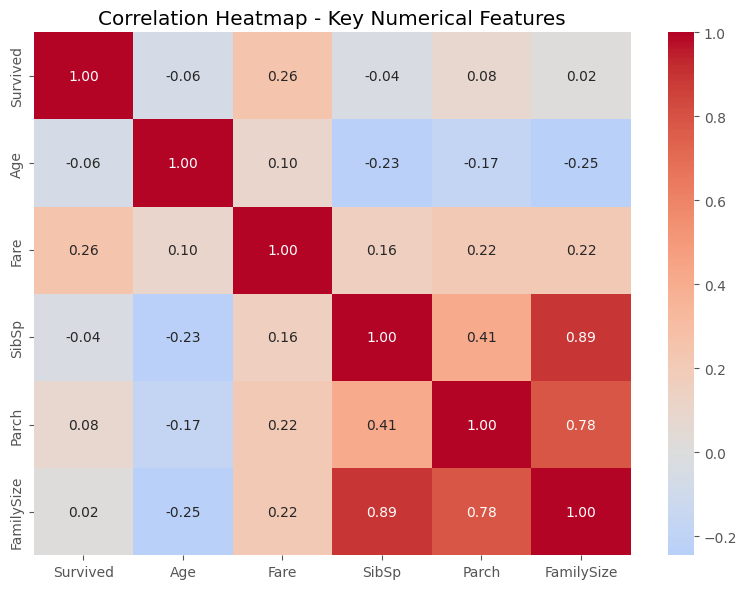

In [13]:
print("=== CORRELATION ANALYSIS ===")

simple_corr = df_clean[['Survived', 'Age', 'Fare', 'SibSp', 'Parch', 'FamilySize']].copy()

simple_corr['Survived'] = simple_corr['Survived'].cat.codes

correlations = simple_corr.corr()['Survived'].sort_values(ascending=False)
print("Correlation with Survival:")
print(correlations.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(simple_corr.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap - Key Numerical Features')
plt.tight_layout()
plt.show()

=== CREATING DIVERSE CHARTS FOR COMPREHENSIVE EDA ===


C:\Users\imaan\AppData\Local\Temp\ipykernel_27064\666367262.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.pointplot(data=title_df, x='Title', y='Survived', ax=axes[2,0],
C:\Users\imaan\AppData\Local\Temp\ipykernel_27064\666367262.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Survived', y='FamilySize', ax=axes[2,1], palette=['#ff9999', '#66b3ff'])


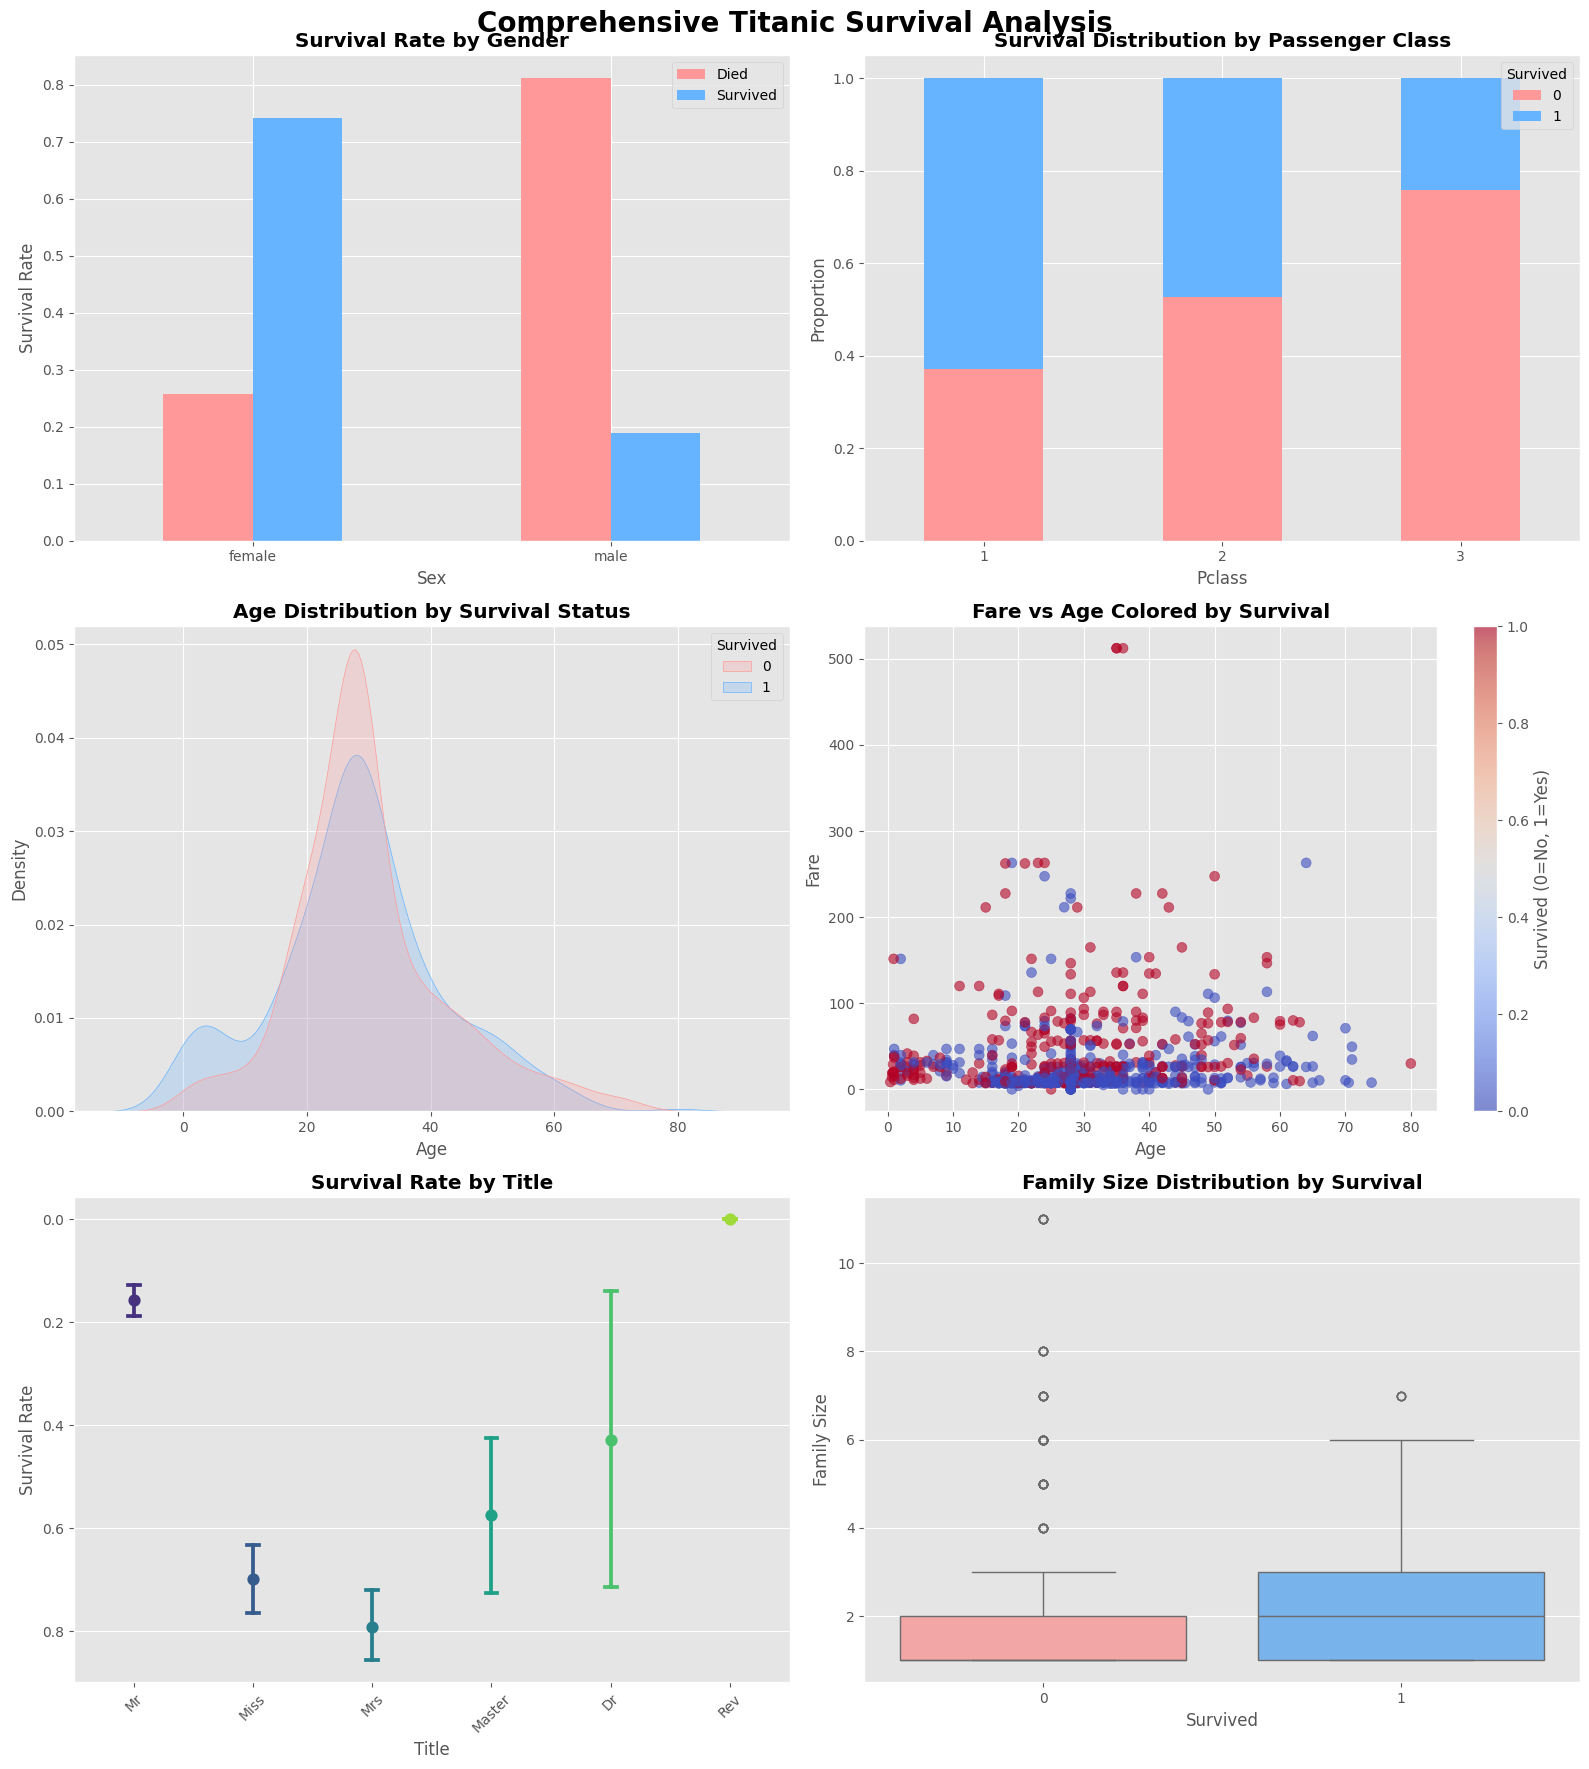

In [14]:
print("=== CREATING DIVERSE CHARTS FOR COMPREHENSIVE EDA ===")

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Comprehensive Titanic Survival Analysis', fontsize=20, fontweight='bold')

gender_survival = pd.crosstab(df_clean['Sex'], df_clean['Survived'], normalize='index')
gender_survival.plot(kind='bar', ax=axes[0,0], color=['#ff9999', '#66b3ff'])
axes[0,0].set_title('Survival Rate by Gender', fontweight='bold')
axes[0,0].set_ylabel('Survival Rate')
axes[0,0].legend(['Died', 'Survived'])
axes[0,0].tick_params(axis='x', rotation=0)

pclass_survival = pd.crosstab(df_clean['Pclass'], df_clean['Survived'], normalize='index')
pclass_survival.plot(kind='bar', stacked=True, ax=axes[0,1], color=['#ff9999', '#66b3ff'])
axes[0,1].set_title('Survival Distribution by Passenger Class', fontweight='bold')
axes[0,1].set_ylabel('Proportion')
axes[0,1].tick_params(axis='x', rotation=0)

sns.kdeplot(data=df_clean, x='Age', hue='Survived', ax=axes[1,0], fill=True, common_norm=False, palette=['#ff9999', '#66b3ff'])
axes[1,0].set_title('Age Distribution by Survival Status', fontweight='bold')
axes[1,0].set_xlabel('Age')

scatter = axes[1,1].scatter(df_clean['Age'], df_clean['Fare'], 
                            c=df_clean['Survived'].cat.codes, 
                            cmap='coolwarm', alpha=0.6, s=50)
axes[1,1].set_title('Fare vs Age Colored by Survival', fontweight='bold')
axes[1,1].set_xlabel('Age')
axes[1,1].set_ylabel('Fare')
plt.colorbar(scatter, ax=axes[1,1], label='Survived (0=No, 1=Yes)')

top_titles = df_clean['Title'].value_counts().head(6).index
title_df = df_clean[df_clean['Title'].isin(top_titles)]
sns.pointplot(data=title_df, x='Title', y='Survived', ax=axes[2,0], 
              order=top_titles, capsize=0.1, palette='viridis')
axes[2,0].set_title('Survival Rate by Title', fontweight='bold')
axes[2,0].set_ylabel('Survival Rate')
axes[2,0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df_clean, x='Survived', y='FamilySize', ax=axes[2,1], palette=['#ff9999', '#66b3ff'])
axes[2,1].set_title('Family Size Distribution by Survival', fontweight='bold')
axes[2,1].set_xlabel('Survived')
axes[2,1].set_ylabel('Family Size')

plt.tight_layout()
plt.show()

In [26]:
print("=== PREPARING DATA FOR MACHINE LEARNING ===")

ml_df = df_clean.copy()

features_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
ml_df = ml_df.drop(columns=features_to_drop)

print("Before conversion - Data types:")
print(ml_df.dtypes)

categorical_cols = ml_df.select_dtypes(['category', 'object']).columns
print(f"Categorical columns to convert: {list(categorical_cols)}")

for col in categorical_cols:
    if ml_df[col].dtype.name == 'category':
        ml_df[col] = ml_df[col].cat.codes
    else:  # object type (like Title)
        ml_df[col] = ml_df[col].astype('category').cat.codes

print("\nAfter conversion - Data types:")
print(ml_df.dtypes)

print(f"\nML Dataset Shape: {ml_df.shape}")
print("Features:", ml_df.columns.tolist())
print("\nFirst 5 rows:")
print(ml_df.head())

=== PREPARING DATA FOR MACHINE LEARNING ===
Before conversion - Data types:
Survived      category
Pclass        category
Sex           category
Age            float64
SibSp            int64
Parch            int64
Fare           float64
Embarked      category
Has_Cabin     category
Title           object
FamilySize       int64
IsAlone       category
AgeGroup      category
FareGroup     category
dtype: object
Categorical columns to convert: ['Survived', 'Pclass', 'Sex', 'Embarked', 'Has_Cabin', 'Title', 'IsAlone', 'AgeGroup', 'FareGroup']

After conversion - Data types:
Survived         int8
Pclass           int8
Sex              int8
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked         int8
Has_Cabin        int8
Title            int8
FamilySize      int64
IsAlone          int8
AgeGroup         int8
FareGroup        int8
dtype: object

ML Dataset Shape: (891, 14)
Features: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 

In [27]:
from sklearn.model_selection import train_test_split

X = ml_df.drop('Survived', axis=1)
y = ml_df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("Survival rate in training set: {:.1f}%".format(y_train.mean() * 100))
print("Survival rate in test set: {:.1f}%".format(y_test.mean() * 100))

Training set size: (712, 13)
Test set size: (179, 13)
Survival rate in training set: 38.3%
Survival rate in test set: 38.5%


In [28]:
from sklearn.preprocessing import StandardScaler

# Scale numerical features
scaler = StandardScaler()

numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Scaling completed! Numerical features normalized.")


Scaling completed! Numerical features normalized.


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Support Vector Machine': SVC(random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n=== {name} ===")
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    
    print(f"Accuracy: {accuracy:.3f}")
    print(f"Classification Report:\n{classification_report(y_test, y_pred)}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"Confusion Matrix:\n{cm}")


=== Logistic Regression ===
Accuracy: 0.804
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       110
           1       0.76      0.72      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179

Confusion Matrix:
[[94 16]
 [19 50]]

=== Random Forest ===
Accuracy: 0.799


C:\Users\imaan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       110
           1       0.74      0.74      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179

Confusion Matrix:
[[92 18]
 [18 51]]

=== Support Vector Machine ===
Accuracy: 0.626
Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.87      0.74       110
           1       0.53      0.23      0.32        69

    accuracy                           0.63       179
   macro avg       0.59      0.55      0.53       179
weighted avg       0.60      0.63      0.58       179

Confusion Matrix:
[[96 14]
 [53 16]]


In [30]:
from sklearn.model_selection import RandomizedSearchCV

# Hyperparameter distribution for random forest
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [4, 6, 8, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42)

search = RandomizedSearchCV(
    rf, 
    param_dist,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

search.fit(X_train_scaled, y_train)

print("Best Hyperparameters:", search.best_params_)
best_rf_model = search.best_estimator_


Best Hyperparameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10}


In [31]:
# Train tuned random forest
best_rf_model.fit(X_train_scaled, y_train)

# Evaluate on training set
train_acc = best_rf_model.score(X_train_scaled, y_train)

# Evaluate on test set
test_acc = best_rf_model.score(X_test_scaled, y_test)

print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

if train_acc - test_acc > 0.1:
    print("⚠️ Model is Overfitting.")
else:
    print("✅ No major overfitting detected.")


Training Accuracy: 0.922752808988764
Test Accuracy: 0.7877094972067039
⚠️ Model is Overfitting.


=== MODEL COMPARISON ===
Model Performance Ranking:
                    Model  Accuracy
0     Logistic Regression  0.804469
1           Random Forest  0.798883
2  Support Vector Machine  0.625698


C:\Users\imaan\AppData\Local\Temp\ipykernel_27064\1623468958.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Accuracy', y='Model', palette='viridis')


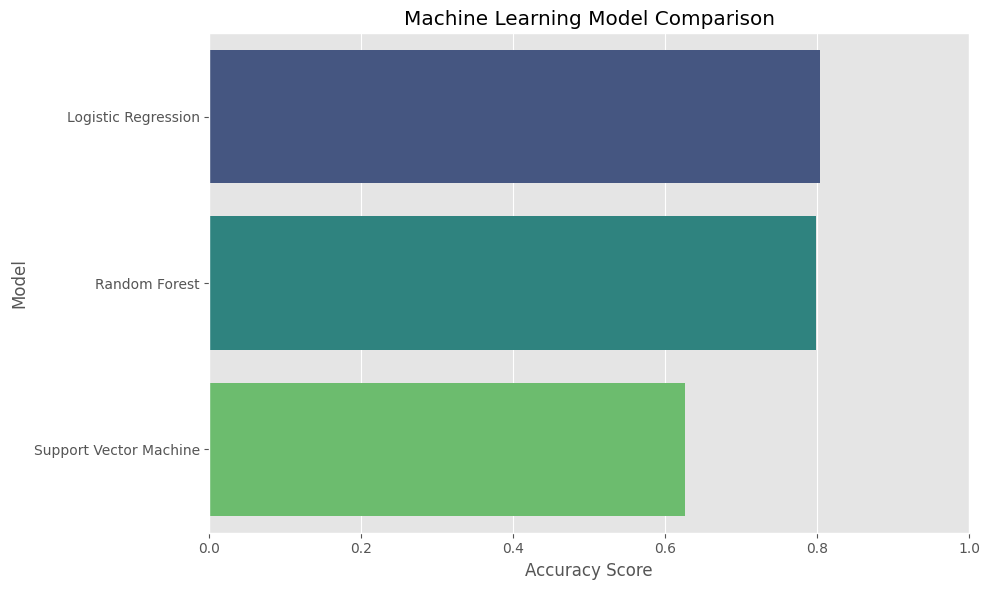


 Best Model: Logistic Regression with 0.804 accuracy

 Top 10 Most Important Features (Random Forest):
       feature  importance
5         Fare    0.197294
1          Sex    0.187218
2          Age    0.177456
8        Title    0.101331
0       Pclass    0.060788
7    Has_Cabin    0.050810
9   FamilySize    0.048435
12   FareGroup    0.044634
11    AgeGroup    0.041118
6     Embarked    0.030740


In [32]:
print("=== MODEL COMPARISON ===")

results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values('Accuracy', ascending=False)

print("Model Performance Ranking:")
print(results_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Accuracy', y='Model', palette='viridis')
plt.title('Machine Learning Model Comparison')
plt.xlim(0, 1)
plt.xlabel('Accuracy Score')
plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]['Model']
best_accuracy = results_df.iloc[0]['Accuracy']
print(f"\n Best Model: {best_model_name} with {best_accuracy:.3f} accuracy")

if 'Random Forest' in models:
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': models['Random Forest'].feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(f"\n Top 10 Most Important Features (Random Forest):")
    print(feature_importance.head(10))

In [33]:
pip install joblib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
# === SAVE THE BEST MODEL ===
import joblib

best_model = models['Logistic Regression']
joblib.dump(best_rf_model, '../models/best_model.pkl')
print("Model saved successfully!")


Model saved successfully!


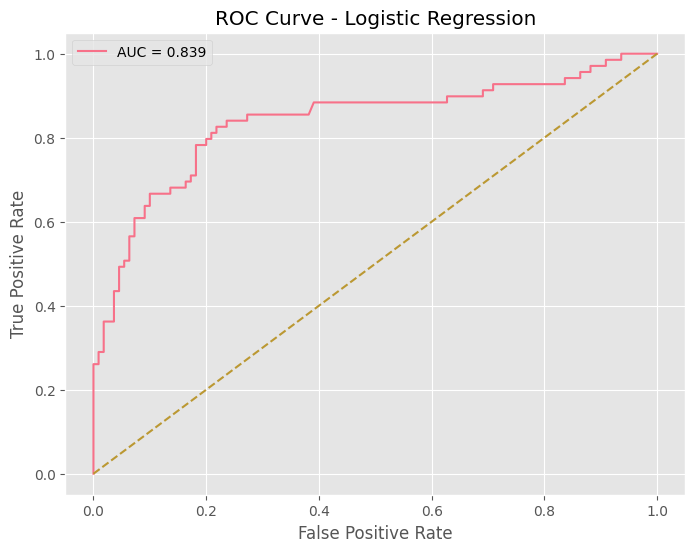

AUC Score: 0.8387351778656126


In [37]:
from sklearn.metrics import roc_curve, auc

best_model = joblib.load('../models/best_model.pkl')

y_pred_prob = best_model.predict_proba(X_test_scaled)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)
